# Notebook 02 — Bases de Pandas
**Auteur** : Louan  
**Objectif** : se familiariser avec Pandas à travers des exercices appliqués à des données financières réelles.

Ce notebook couvre :
- Création et manipulation de Series et DataFrames
- Chargement de données depuis Internet
- Indexation, filtrage, séries temporelles
- Calcul de rendements et de moyennes mobiles
- Visualisation

## Exercice 1 — Création et exploration d'un DataFrame
On crée manuellement un petit DataFrame de prix et de volumes pour se familiariser avec les opérations de base.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.DataFrame(
    {
        'prix': [100, 102, 101, 105, 103, 107, 108, 110, 109, 112],
        'volume': [1000, 1200, 900, 1500, 1100, 1300, 1400, 1600, 1250, 1700]
    },
    index=pd.date_range('2024-01-01', periods=10, freq='D')
)

print("DataFrame complet :")
print(df)

print(f"\nShape : {df.shape}")
print(f"\nDtypes :\n{df.dtypes}")
print(f"\nStatistiques descriptives :\n{df.describe()}")
print(f"\nMoyennes :\n{df.mean()}")

print(f"\nLignes où prix > 105 :")
print(df[df['prix'] > 105])

df['rendement'] = df['prix'].pct_change()

print(f"\nDataFrame avec rendement :")
print(df)

DataFrame complet :
            prix  volume
2024-01-01   100    1000
2024-01-02   102    1200
2024-01-03   101     900
2024-01-04   105    1500
2024-01-05   103    1100
2024-01-06   107    1300
2024-01-07   108    1400
2024-01-08   110    1600
2024-01-09   109    1250
2024-01-10   112    1700

Shape : (10, 2)

Dtypes :
prix      int64
volume    int64
dtype: object

Statistiques descriptives :
             prix      volume
count   10.000000    10.00000
mean   105.700000  1295.00000
std      4.110961   258.68256
min    100.000000   900.00000
25%    102.250000  1125.00000
50%    106.000000  1275.00000
75%    108.750000  1475.00000
max    112.000000  1700.00000

Moyennes :
prix       105.7
volume    1295.0
dtype: float64

Lignes où prix > 105 :
            prix  volume
2024-01-06   107    1300
2024-01-07   108    1400
2024-01-08   110    1600
2024-01-09   109    1250
2024-01-10   112    1700

DataFrame avec rendement :
            prix  volume  rendement
2024-01-01   100    1000        Na

## Exercice 2 — Charger des vraies données de marché depuis Internet

On télécharge l'historique mensuel du S&P 500 directement depuis un dépôt GitHub public. C'est ton premier contact avec des données réelles.

Source : https://github.com/datasets/s-and-p-500 (données mensuelles depuis 1871, basées sur les travaux de Robert Shiller, prix Nobel 2013).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

print("5 premières lignes :")
print(sp500.head())
print(f"\n5 dernières lignes :")
print(sp500.tail())
print(f"\nShape : {sp500.shape}")
print(f"\nDtypes :")
print(sp500.dtypes)
print(f"\nValeurs manquantes par colonne :")
print(sp500.isna().sum())

5 premières lignes :
         Date  SP500  Dividend  Earnings  Consumer Price Index  \
0  1871-01-01   4.44      0.26       0.4                 12.46   
1  1871-02-01   4.50      0.26       0.4                 12.84   
2  1871-03-01   4.61      0.26       0.4                 13.03   
3  1871-04-01   4.74      0.26       0.4                 12.56   
4  1871-05-01   4.86      0.26       0.4                 12.27   

   Long Interest Rate  Real Price  Real Dividend  Real Earnings  PE10  
0                5.32      109.05           6.39           9.82   0.0  
1                5.32      107.25           6.20           9.53   0.0  
2                5.33      108.27           6.11           9.39   0.0  
3                5.33      115.54           6.34           9.75   0.0  
4                5.33      121.22           6.48           9.98   0.0  

5 dernières lignes :
            Date    SP500  Dividend  Earnings  Consumer Price Index  \
1860  2026-01-01  6929.12       0.0       0.0            

## Exercice 3 — Séries temporelles : datetime, index et premier graphe

Le DataFrame chargé a une colonne `Date` lue comme du texte. On va :
1. Garder uniquement `Date` et `SP500`
2. Convertir `Date` en vrai datetime
3. Mettre `Date` en index
4. Calculer les rendements mensuels
5. Tracer la courbe historique du S&P 500

5 premières lignes :
            SP500  rendement
Date                        
1871-01-01   4.44        NaN
1871-02-01   4.50   0.013514
1871-03-01   4.61   0.024444
1871-04-01   4.74   0.028200
1871-05-01   4.86   0.025316

5 dernières lignes :
              SP500  rendement
Date                          
2026-01-01  6929.12   0.011103
2026-02-01  6893.81  -0.005096
2026-03-01  6654.42  -0.034725
2026-04-01  6957.01   0.045472
2026-05-01  7412.55   0.065479

Index : DatetimeIndex(['1871-01-01', '1871-02-01', '1871-03-01', '1871-04-01',
               '1871-05-01', '1871-06-01', '1871-07-01', '1871-08-01',
               '1871-09-01', '1871-10-01',
               ...
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01'],
              dtype='datetime64[us]', name='Date', length=1865, freq=None)

Dtypes :
SP500        float64
rendement    float64
dtype: obje

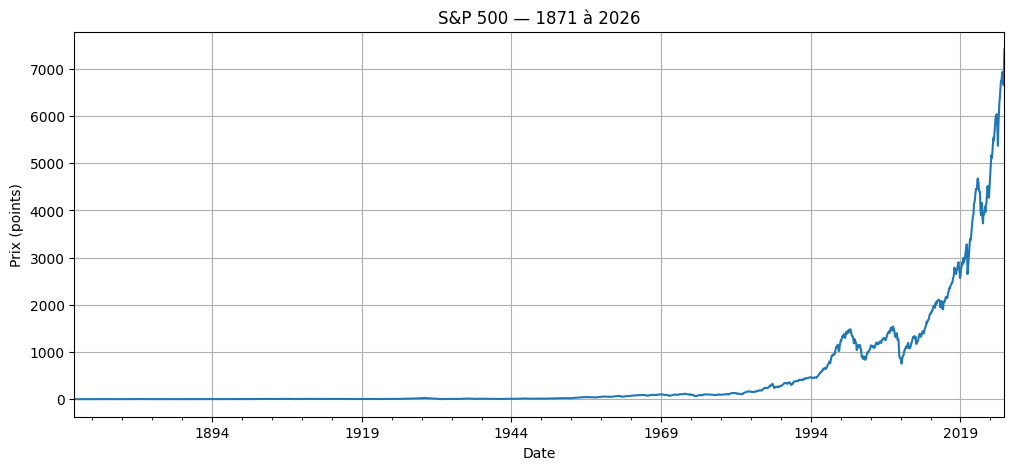

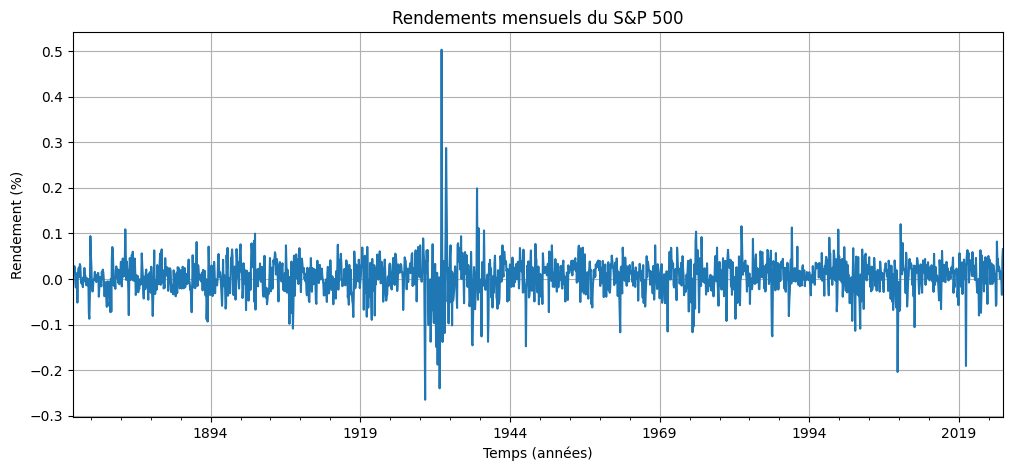

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

# Étape 1 — Garder uniquement Date et SP500
sp = sp500[['Date', 'SP500']].copy()

# Étape 2 — Convertir Date en datetime
sp['Date'] = pd.to_datetime(sp['Date'])

# Étape 3 — Mettre Date en index
sp = sp.set_index('Date')

# Étape 4 — Calculer les rendements mensuels
sp['rendement'] = sp['SP500'].pct_change()

# Étape 5 — Inspection
print("5 premières lignes :")
print(sp.head())
print("\n5 dernières lignes :")
print(sp.tail())
print(f"\nIndex : {sp.index}")
print(f"\nDtypes :")
print(sp.dtypes)

# Étape 6 — Premier graphe
sp['SP500'].plot(figsize=(12, 5), title='S&P 500 — 1871 à 2026', grid=True)
plt.ylabel('Prix (points)')
plt.show()

sp['rendement'].plot(figsize=(12, 5), title='Rendements mensuels du S&P 500', grid=True)
plt.ylabel('Rendement (%)')
plt.xlabel('Temps (années)')
plt.show()

Suite exercice 3 avec rendements annualisés, volatilité et sharpe ratio du sp500

            rendement_moy  volatilite    sharpe
Date                                           
2025-08-01       0.152374    0.122389  1.244992
2025-09-01       0.186171    0.111234  1.673685
2025-10-01       0.204625    0.107604  1.901650
2025-11-01       0.187756    0.106024  1.770883
2025-12-01       0.193736    0.105545  1.835569
2026-01-01       0.193324    0.105563  1.831358
2026-02-01       0.181608    0.105921  1.714551
2026-03-01       0.179112    0.107031  1.673466
2026-04-01       0.181426    0.107629  1.685664
2026-05-01       0.201254    0.111316  1.807954


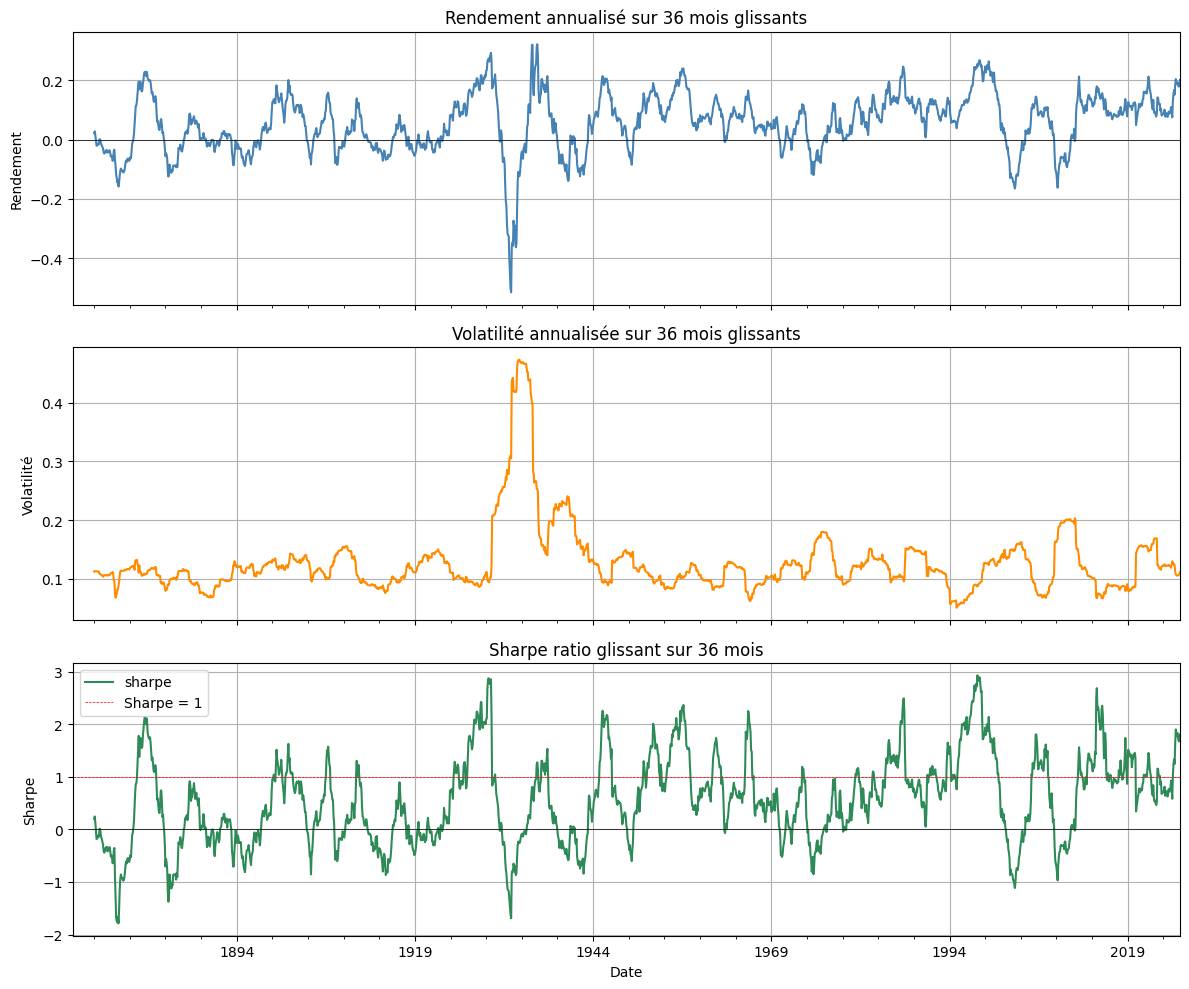

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

# Étape 1 — Garder uniquement Date et SP500
sp = sp500[['Date', 'SP500']].copy()

# Étape 2 — Convertir Date en datetime
sp['Date'] = pd.to_datetime(sp['Date'])

# Étape 3 — Mettre Date en index
sp = sp.set_index('Date')

# Étape 4 — Calculer les rendements mensuels
sp['rendement'] = sp['SP500'].pct_change()

WINDOW = 36

# 1. Rendement moyen glissant (annualisé)
sp['rendement_moy'] = sp['rendement'].rolling(window=WINDOW).mean() * 12

# 2. Volatilité glissante (annualisée)
sp['volatilite'] = sp['rendement'].rolling(window=WINDOW).std() * np.sqrt(12)

# 3. Sharpe ratio glissant
sp['sharpe'] = sp['rendement_moy'] / sp['volatilite']

# Affichage rapide
print(sp[['rendement_moy', 'volatilite', 'sharpe']].tail(10))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

sp['rendement_moy'].plot(ax=axes[0], color='steelblue', grid=True,
                         title=f'Rendement annualisé sur {WINDOW} mois glissants')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Rendement')

sp['volatilite'].plot(ax=axes[1], color='darkorange', grid=True,
                      title=f'Volatilité annualisée sur {WINDOW} mois glissants')
axes[1].set_ylabel('Volatilité')

sp['sharpe'].plot(ax=axes[2], color='seagreen', grid=True,
                  title=f'Sharpe ratio glissant sur {WINDOW} mois')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axhline(1, color='red', linewidth=0.5, linestyle='--', label='Sharpe = 1')
axes[2].set_ylabel('Sharpe')
axes[2].legend()

plt.tight_layout()
plt.show()

Suite 2 exercie 3 : volatilité, sharpe et rendements moyens

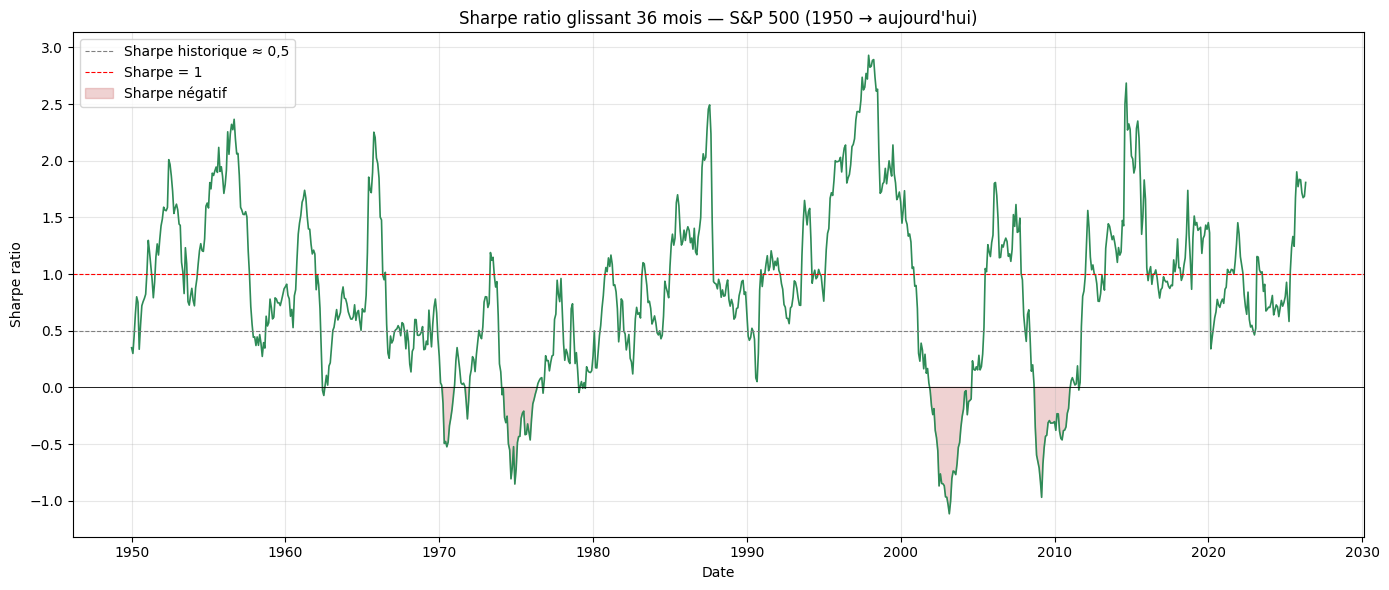

In [28]:
# Filtrer à partir de 1950
sharpe_moderne = sp.loc[sp.index >= '1950-01-01', 'sharpe']

plt.figure(figsize=(14, 6))
plt.plot(sharpe_moderne.index, sharpe_moderne.values, color='seagreen', linewidth=1.2)

# Lignes de référence
plt.axhline(0,   color='black', linewidth=0.6)
plt.axhline(0.5, color='gray',  linewidth=0.8, linestyle='--', label='Sharpe historique ≈ 0,5')
plt.axhline(1,   color='red',   linewidth=0.8, linestyle='--', label='Sharpe = 1')

# Zone négative en rouge transparent
plt.fill_between(sharpe_moderne.index, sharpe_moderne.values, 0,
                 where=(sharpe_moderne.values < 0),
                 color='firebrick', alpha=0.2, label='Sharpe négatif')

plt.title('Sharpe ratio glissant 36 mois — S&P 500 (1950 → aujourd\'hui)')
plt.xlabel('Date')
plt.ylabel('Sharpe ratio')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercice 4 — Moyenne mobile sur 12 mois

On ajoute une moyenne mobile sur 12 mois (1 an) au DataFrame, et on la superpose à la courbe des prix pour voir comment elle "lisse" les variations à court terme.

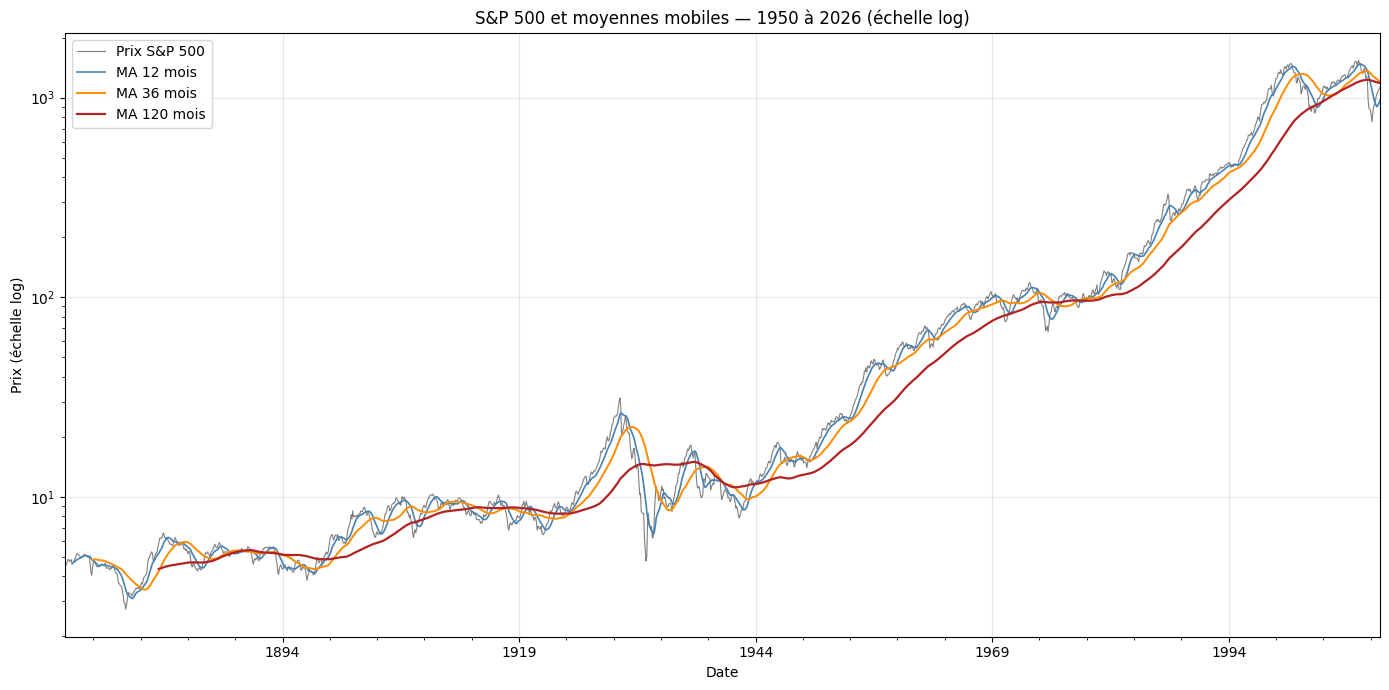

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

# Étape 1 — Garder uniquement Date et SP500
sp = sp500[['Date', 'SP500']].copy()

# Étape 2 — Convertir Date en datetime
sp['Date'] = pd.to_datetime(sp['Date'])

# Étape 3 — Mettre Date en index
sp = sp.set_index('Date')

# Étape 4 — Calculer les rendements mensuels
sp['rendement'] = sp['SP500'].pct_change()


# Moyennes mobiles de différentes longueurs
sp['MA_12']  = sp['SP500'].rolling(window=12).mean()    # 1 an
sp['MA_36']  = sp['SP500'].rolling(window=36).mean()    # 3 ans
sp['MA_120'] = sp['SP500'].rolling(window=120).mean()   # 10 ans

# Graphe global — depuis 1950, échelle log
sp_mod = sp.loc[sp.index >= '2007-01-01']
sp_mod = sp.loc[sp.index <= '2010-01-01']

fig, ax = plt.subplots(figsize=(14, 7))
sp_mod['SP500'].plot(ax=ax, color='black',      linewidth=0.8, label='Prix S&P 500', alpha=0.5)
sp_mod['MA_12'].plot( ax=ax, color='steelblue',  linewidth=1.2, label='MA 12 mois')
sp_mod['MA_36'].plot( ax=ax, color='darkorange', linewidth=1.4, label='MA 36 mois ')
sp_mod['MA_120'].plot(ax=ax, color='firebrick',  linewidth=1.6, label='MA 120 mois')

ax.set_yscale('log')
ax.set_title('S&P 500 et moyennes mobiles — 1950 à 2026 (échelle log)')
ax.set_ylabel('Prix (échelle log)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Exercice 4 bis + intro de l exo 5

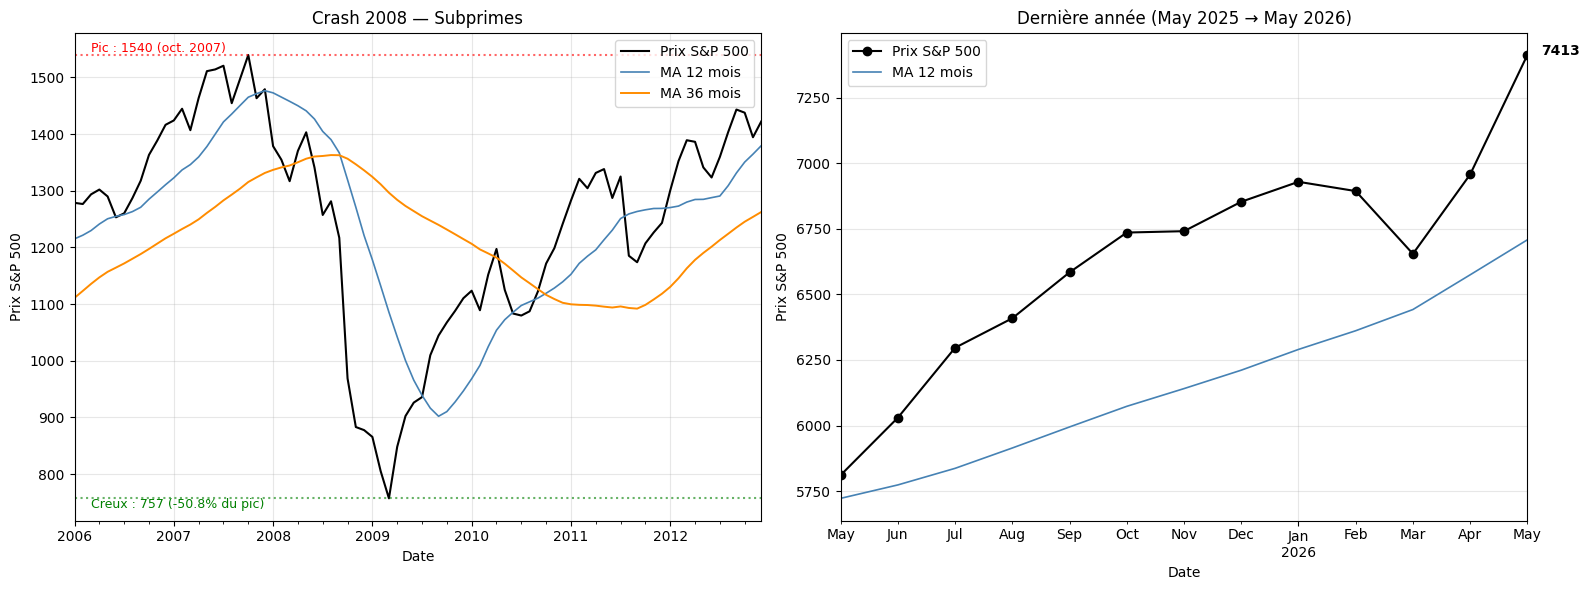


Crash 2008 :
  Pic (oct. 2007)   : 1540
  Creux (mars 2009) : 757
  Chute totale      : -50.8%
  Durée pic→creux   : 517 jours

Dernière année :
  Début (May 2025)   : 5811
  Fin   (May 2026)   : 7413
  Performance 12m    : +27.6%


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
URL = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"

sp500 = pd.read_csv(URL)

# Étape 1 — Garder uniquement Date et SP500
sp = sp500[['Date', 'SP500']].copy()

# Étape 2 — Convertir Date en datetime
sp['Date'] = pd.to_datetime(sp['Date'])

# Étape 3 — Mettre Date en index
sp = sp.set_index('Date')

# Étape 4 — Calculer les rendements mensuels
sp['rendement'] = sp['SP500'].pct_change()


# Moyennes mobiles de différentes longueurs
sp['MA_12']  = sp['SP500'].rolling(window=12).mean()    # 1 an
sp['MA_36']  = sp['SP500'].rolling(window=36).mean()    # 3 ans
sp['MA_120'] = sp['SP500'].rolling(window=120).mean()   # 10 ans

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ═══════════════════════════════════════════════
# Graphe 1 — Crash 2008 (zoom 2006 → 2012)
# ═══════════════════════════════════════════════
sp_2008 = sp.loc['2006-01-01':'2012-12-31']

sp_2008['SP500'].plot(ax=axes[0], color='black',      linewidth=1.5, label='Prix S&P 500')
sp_2008['MA_12'].plot(ax=axes[0], color='steelblue',  linewidth=1.2, label='MA 12 mois')
sp_2008['MA_36'].plot(ax=axes[0], color='darkorange', linewidth=1.4, label='MA 36 mois')

# Marquage du pic (oct 2007) et du creux (mars 2009)
pic   = sp.loc['2007-10-01', 'SP500']
creux = sp.loc['2009-03-01', 'SP500']
chute_pct = (creux - pic) / pic * 100

axes[0].axhline(pic,   color='red',   linestyle=':', alpha=0.6)
axes[0].axhline(creux, color='green', linestyle=':', alpha=0.6)
axes[0].annotate(f'Pic : {pic:.0f} (oct. 2007)',
                 xy=(pd.to_datetime('2006-03-01'), pic),
                 color='red', fontsize=9, va='bottom')
axes[0].annotate(f'Creux : {creux:.0f} ({chute_pct:.1f}% du pic)',
                 xy=(pd.to_datetime('2006-03-01'), creux),
                 color='green', fontsize=9, va='top')

axes[0].set_title('Crash 2008 — Subprimes')
axes[0].set_ylabel('Prix S&P 500')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ═══════════════════════════════════════════════
# Graphe 2 — Dernière année du dataset
# ═══════════════════════════════════════════════
derniere_date = sp.index.max()
debut         = derniere_date - pd.DateOffset(years=1)
sp_recent     = sp.loc[debut:derniere_date]

sp_recent['SP500'].plot(ax=axes[1], color='black',     linewidth=1.5,
                        marker='o', markersize=6, label='Prix S&P 500')
sp_recent['MA_12'].plot(ax=axes[1], color='steelblue', linewidth=1.2,
                        label='MA 12 mois')

# Annotation du dernier point
dernier_prix = sp_recent['SP500'].iloc[-1]
axes[1].annotate(f'{dernier_prix:.0f}',
                 xy=(derniere_date, dernier_prix),
                 xytext=(10, 0), textcoords='offset points',
                 fontsize=10, fontweight='bold')

axes[1].set_title(f'Dernière année ({debut.strftime("%b %Y")} → {derniere_date.strftime("%b %Y")})')
axes[1].set_ylabel('Prix S&P 500')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stats de contexte
print(f"\nCrash 2008 :")
print(f"  Pic (oct. 2007)   : {pic:.0f}")
print(f"  Creux (mars 2009) : {creux:.0f}")
print(f"  Chute totale      : {chute_pct:.1f}%")
print(f"  Durée pic→creux   : {(pd.to_datetime('2009-03-01') - pd.to_datetime('2007-10-01')).days} jours")

print(f"\nDernière année :")
print(f"  Début ({debut.strftime('%b %Y')})   : {sp_recent['SP500'].iloc[0]:.0f}")
print(f"  Fin   ({derniere_date.strftime('%b %Y')})   : {sp_recent['SP500'].iloc[-1]:.0f}")
perf_recent = (sp_recent['SP500'].iloc[-1] / sp_recent['SP500'].iloc[0] - 1) * 100
print(f"  Performance 12m    : {perf_recent:+.1f}%")

## Exercice 5 — Drawdown maximum

Le drawdown mesure la perte depuis le plus haut historique. Le max drawdown
est la pire douleur jamais ressentie par un investisseur sur la période.

On va :
1. Calculer le peak cumulé et le drawdown à chaque date
2. Identifier le pire drawdown historique (valeur, dates, durée, récupération)
3. Tracer un underwater chart (visualisation classique en finance)

═══ Pire drawdown historique du S&P 500 ═══

  Drawdown maximum  : -84.76%
  Pic    : 1929-09-01   (prix = 31.30)
  Creux  : 1932-06-01   (prix = 4.77)
  Durée pic → creux : 1004 jours (~2.8 ans)
  Récupération : 1954-09-01
  Durée creux → récup : 8127 jours (~22.3 ans)
  Durée TOTALE du drawdown : 9131 jours (~25.0 ans)

═══ Drawdowns aux dates de crises connues ═══
  Grande Dépression (trough)     1932-06-01 | prix=      5 | peak=     31 | DD= -84.76%
  Choc pétrolier (trough)        1974-09-01 | prix=     68 | peak=    118 | DD= -42.47%
  Dotcom (trough)                2002-09-01 | prix=    868 | peak=   1485 | DD= -41.58%
  Subprimes (trough)             2009-03-01 | prix=    757 | peak=   1540 | DD= -50.82%
  COVID (trough)                 2020-03-01 | prix=   2652 | peak=   3278 | DD= -19.09%


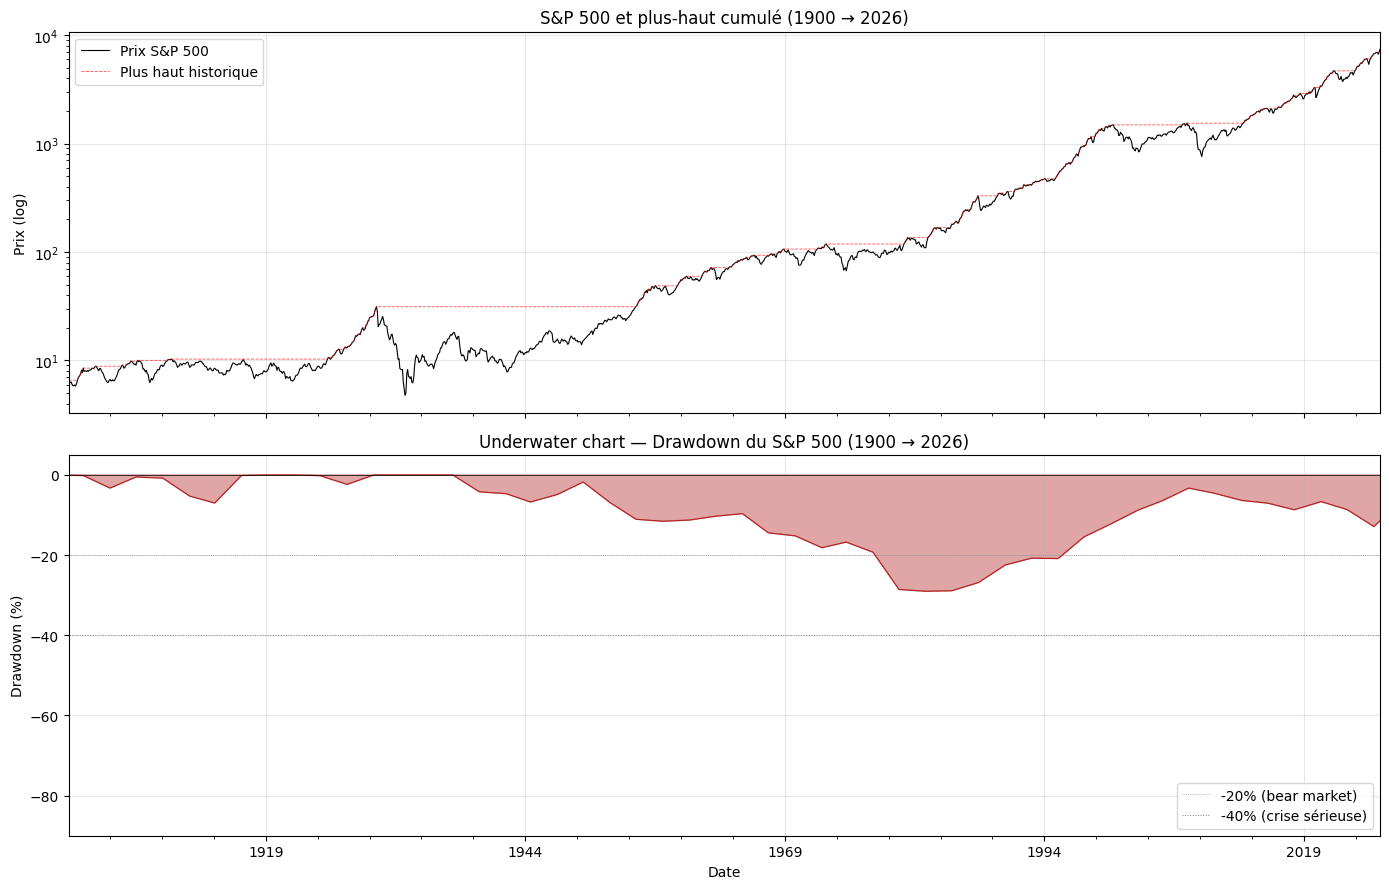

In [9]:
# ═══════════════════════════════════════════════════════
# Exercice 5 — Drawdown maximum du S&P 500
# ═══════════════════════════════════════════════════════

# ─── Étape 1 — Calcul du peak cumulé et du drawdown ───
sp['peak']     = sp['SP500'].cummax()
sp['drawdown'] = (sp['SP500'] - sp['peak']) / sp['peak']

# ─── Étape 2 — Stats du pire drawdown historique ───
max_dd     = sp['drawdown'].min()
date_creux = sp['drawdown'].idxmin()
date_pic   = sp.loc[:date_creux, 'SP500'].idxmax()
prix_pic   = sp.loc[date_pic,   'SP500']
prix_creux = sp.loc[date_creux, 'SP500']

mask_recovery = (sp.index > date_creux) & (sp['SP500'] >= prix_pic)
if mask_recovery.any():
    date_recovery  = sp.index[mask_recovery][0]
    duree_recovery = (date_recovery - date_creux).days
else:
    date_recovery  = None
    duree_recovery = None

duree_chute = (date_creux - date_pic).days

print("═══ Pire drawdown historique du S&P 500 ═══\n")
print(f"  Drawdown maximum  : {max_dd*100:.2f}%")
print(f"  Pic    : {date_pic.strftime('%Y-%m-%d')}   (prix = {prix_pic:.2f})")
print(f"  Creux  : {date_creux.strftime('%Y-%m-%d')}   (prix = {prix_creux:.2f})")
print(f"  Durée pic → creux : {duree_chute} jours (~{duree_chute/365:.1f} ans)")
if date_recovery:
    print(f"  Récupération : {date_recovery.strftime('%Y-%m-%d')}")
    print(f"  Durée creux → récup : {duree_recovery} jours (~{duree_recovery/365:.1f} ans)")
    print(f"  Durée TOTALE du drawdown : {(date_recovery - date_pic).days} jours "
          f"(~{(date_recovery - date_pic).days/365:.1f} ans)")
else:
    print("  ⚠️ Pas encore récupéré à la date de fin du dataset")

# ─── Étape 3 — Vérification aux dates de crises connues ───
print("\n═══ Drawdowns aux dates de crises connues ═══")
crises_verif = {
    'Grande Dépression (trough)': '1932-06-01',
    'Choc pétrolier (trough)'   : '1974-09-01',
    'Dotcom (trough)'           : '2002-09-01',
    'Subprimes (trough)'        : '2009-03-01',
    'COVID (trough)'            : '2020-03-01',
}
for nom, date in crises_verif.items():
    prix = sp.loc[date, 'SP500']
    peak = sp.loc[date, 'peak']
    dd   = sp.loc[date, 'drawdown'] * 100
    print(f"  {nom:30s} {date} | prix={prix:7.0f} | peak={peak:7.0f} | DD={dd:7.2f}%")


# ═══════════════════════════════════════════════════════
# Étape 4 — Graphe à 2 panneaux : prix + underwater chart
# ═══════════════════════════════════════════════════════

sp_long = sp.loc['1900-01-01':]   # depuis 1900 pour inclure 1929

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ─── Panneau du haut : prix + plus-haut cumulé ───
sp_long['SP500'].plot(ax=axes[0], color='black', linewidth=0.8,
                     label='Prix S&P 500')
sp_long['peak'].plot(ax=axes[0],  color='red',   linewidth=0.6,
                     linestyle='--', alpha=0.7, label='Plus haut historique')
axes[0].set_yscale('log')
axes[0].set_title('S&P 500 et plus-haut cumulé (1900 → 2026)')
axes[0].set_ylabel('Prix (log)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# ─── Panneau du bas : underwater chart ───
axes[1].fill_between(sp_long.index, sp_long['drawdown']*100, 0,
                     color='firebrick', alpha=0.4)
axes[1].plot(sp_long.index, sp_long['drawdown']*100,
             color='firebrick', linewidth=0.8)

# Seuils de référence
axes[1].axhline(0,   color='black', linewidth=0.5)
axes[1].axhline(-20, color='gray',  linewidth=0.5, linestyle=':', label='-20% (bear market)')
axes[1].axhline(-40, color='gray',  linewidth=0.7, linestyle=':', label='-40% (crise sérieuse)')

# Annotations des creux historiques
crises_annot = {
    '1932-06-01': ('Grande Dépression', -84.76),
    '1974-09-01': ('Choc pétrolier',    -42.47),
    '2002-09-01': ('Dotcom',            -41.58),
    '2009-03-01': ('Subprimes',         -50.82),
    '2020-03-01': ('COVID',             -19.09),
}
for date, (nom, dd) in crises_annot.items():
    axes[1].annotate(f'{nom}\n{dd:.1f}%',
                     xy=(pd.to_datetime(date), dd),
                     xytext=(0, -18), textcoords='offset points',
                     ha='center', fontsize=8, color='darkred',
                     arrowprops=dict(arrowstyle='->', color='darkred', alpha=0.6))

axes[1].set_title('Underwater chart — Drawdown du S&P 500 (1900 → 2026)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-90, 5)   # forcer l'axe pour voir 1932

plt.tight_layout()
plt.show()